
# Multiple Linear Regression — Bike Sharing Demand Prediction

**Objective:** Build and evaluate a multiple linear regression model to predict daily bike demand (`cnt`), following a clean, professional workflow:
1. Import libraries & data
2. Exploratory Data Analysis (EDA)
3. Preprocessing & Feature Engineering
4. Multicollinearity check (VIF)
5. Model building (Statsmodels & scikit-learn)
6. Model evaluation & diagnostics
7. Insights & recommendations


## 1. Importing Libraries
We import:
- **Data handling:** `pandas`, `numpy`
- **Visualization:** `matplotlib`, `seaborn`
- **Modeling:** `statsmodels`, `scikit-learn`
- **Diagnostics:** Variance Inflation Factor (VIF) for multicollinearity.


In [15]:

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

sns.set(style='whitegrid')
%matplotlib inline


## 2. Loading the Dataset
The dataset contains daily bike rental counts along with weather and calendar information.
We first check:
- Shape of the dataset
- A preview of the first few rows


In [16]:

# Load dataset (update path as needed)
file_path = "Mulitple_Regression_dataSet.csv"
df = pd.read_csv(file_path)

print("Shape:", df.shape)
df.head()


Shape: (730, 16)


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,01-01-2018,1,0,1,0,6,0,2,14.110847,18.18125,80.5833,10.749882,331,654,985
1,2,02-01-2018,1,0,1,0,0,0,2,14.902598,17.68695,69.6087,16.652113,131,670,801
2,3,03-01-2018,1,0,1,0,1,1,1,8.050924,9.47025,43.7273,16.636703,120,1229,1349
3,4,04-01-2018,1,0,1,0,2,1,1,8.200000,10.60610,59.0435,10.739832,108,1454,1562
4,5,05-01-2018,1,0,1,0,3,1,1,9.305237,11.46350,43.6957,12.522300,82,1518,1600


## 3. Data Overview
We examine:
- Data types of each column
- Missing values
- Summary statistics for numeric columns


In [17]:

print("Info:")
print(df.info())

print("\nMissing values per column:")
print(df.isnull().sum())

df.describe().T


Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     730 non-null    int64  
 1   dteday      730 non-null    object 
 2   season      730 non-null    int64  
 3   yr          730 non-null    int64  
 4   mnth        730 non-null    int64  
 5   holiday     730 non-null    int64  
 6   weekday     730 non-null    int64  
 7   workingday  730 non-null    int64  
 8   weathersit  730 non-null    int64  
 9   temp        730 non-null    float64
 10  atemp       730 non-null    float64
 11  hum         730 non-null    float64
 12  windspeed   730 non-null    float64
 13  casual      730 non-null    int64  
 14  registered  730 non-null    int64  
 15  cnt         730 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.4+ KB
None

Missing values per column:
instant       0
dteday        0
season        0
yr    

,count,mean,std,min,25%,50%,75%,max
instant,730.0,365.500000,210.877136,1.000000,183.250000,365.500000,547.750000,730.000000
season,730.0,2.498630,1.110184,1.000000,2.000000,3.000000,3.000000,4.000000
yr,730.0,0.500000,0.500343,0.000000,0.000000,0.500000,1.000000,1.000000
mnth,730.0,6.526027,3.450215,1.000000,4.000000,7.000000,10.000000,12.000000
holiday,730.0,0.028767,0.167266,0.000000,0.000000,0.000000,0.000000,1.000000
weekday,730.0,2.997260,2.006161,0.000000,1.000000,3.000000,5.000000,6.000000
workingday,730.0,0.683562,0.465405,0.000000,0.000000,1.000000,1.000000,1.000000
weathersit,730.0,1.394521,0.544807,1.000000,1.000000,1.000000,2.000000,3.000000
temp,730.0,20.319259,7.506729,2.424346,13.811885,20.465826,26.880615,35.328347
atemp,730.0,23.726322,8.150308,3.953480,16.889713,24.368225,30.445775,42.044800


## 4. Feature Engineering
From the `dteday` column:
- Extract **day of month**
- Create `is_weekend` flag (1 = weekend, 0 = weekday)

We drop:
- `instant` (index-like column)
- Original `dteday` column


In [18]:

# Convert date column to datetime and extract features
df['dteday'] = pd.to_datetime(df['dteday'], dayfirst=True)
df['day'] = df['dteday'].dt.day
df['is_weekend'] = df['weekday'].isin([0,6]).astype(int)

# Drop 'instant' (index-like) and original date column
df.drop(columns=['instant', 'dteday'], inplace=True)


## 5. Exploratory Data Analysis (EDA)
We explore relationships between features and target (`cnt`) through:
- Histograms for numerical features
- Correlation heatmap
- Boxplots of categorical features vs. `cnt`


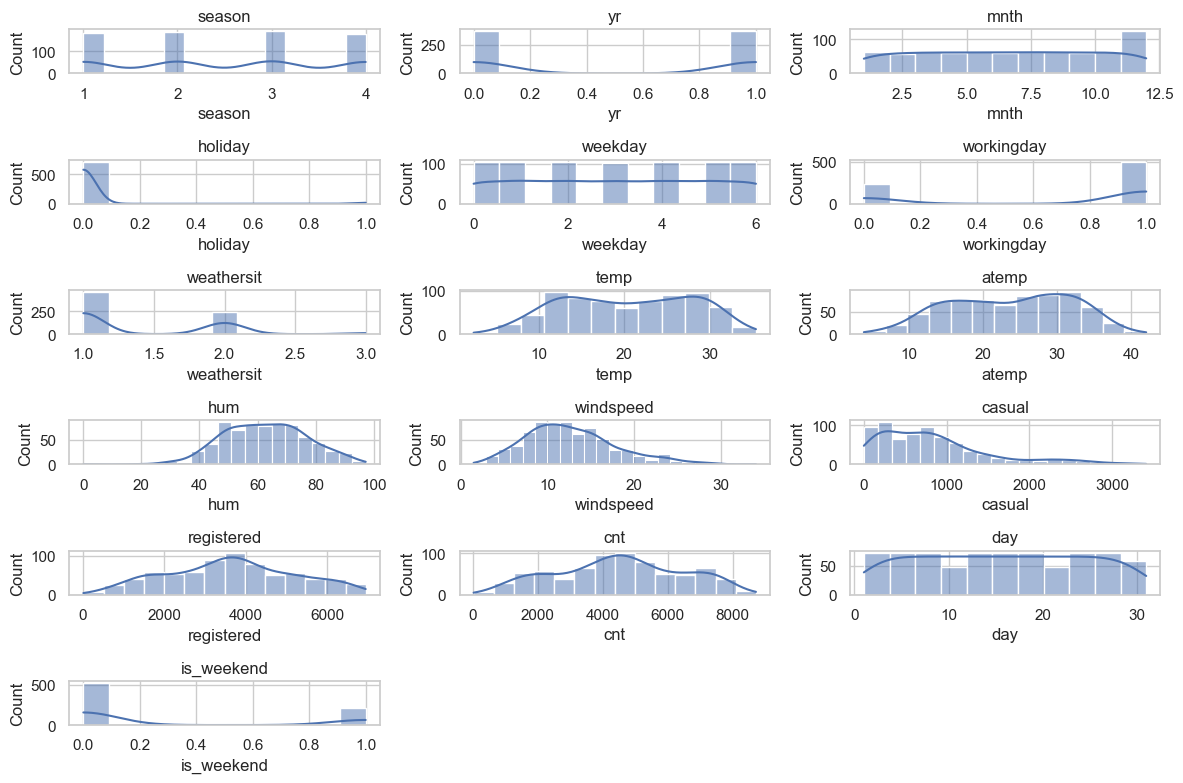

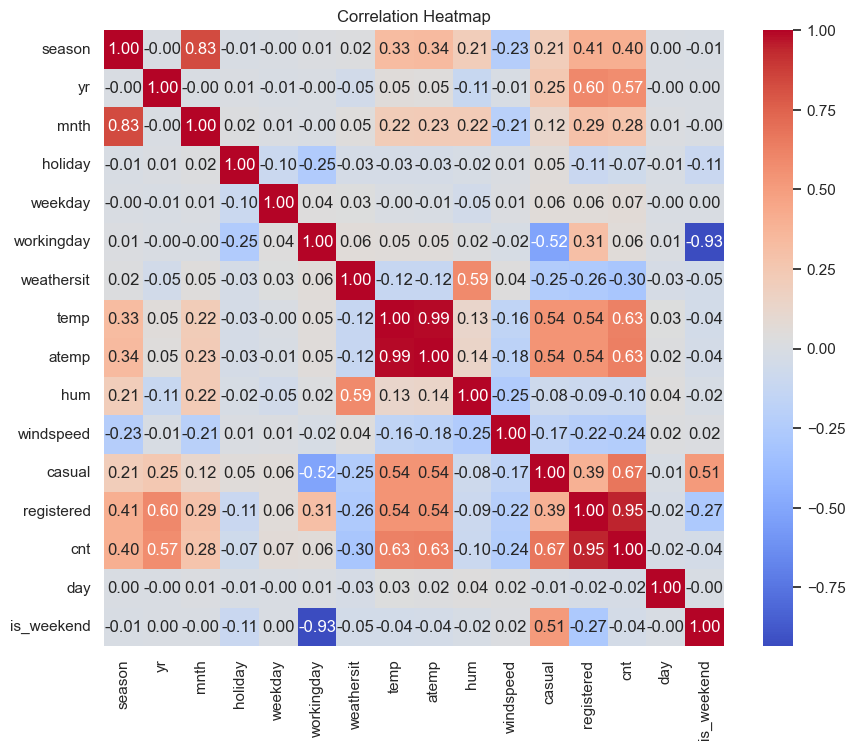

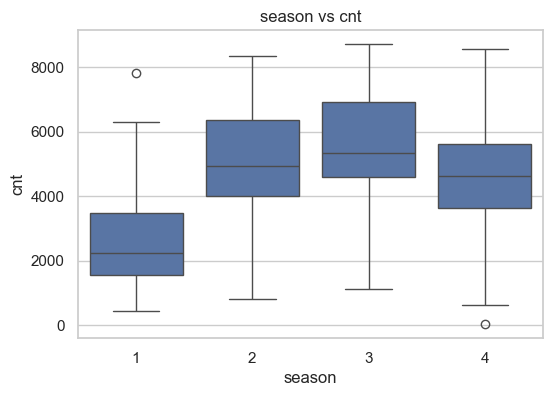

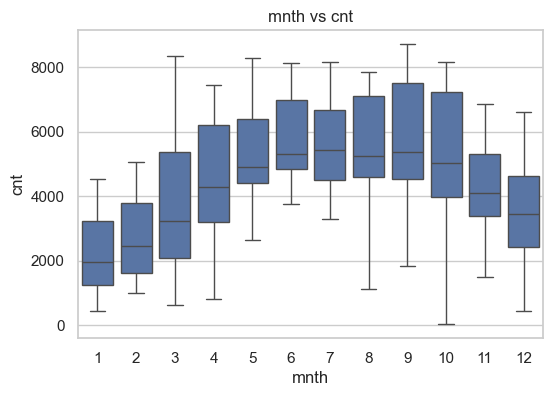

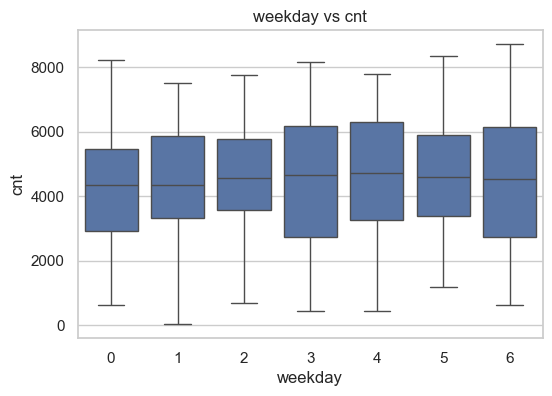

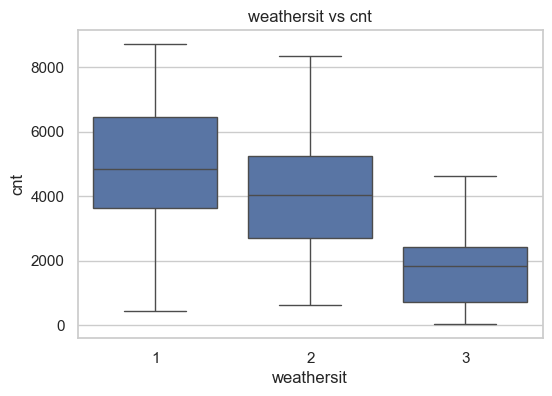

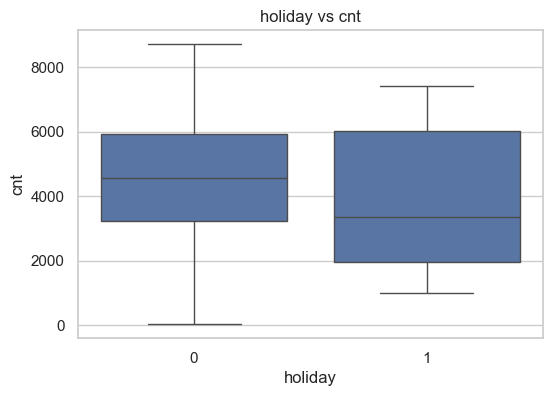

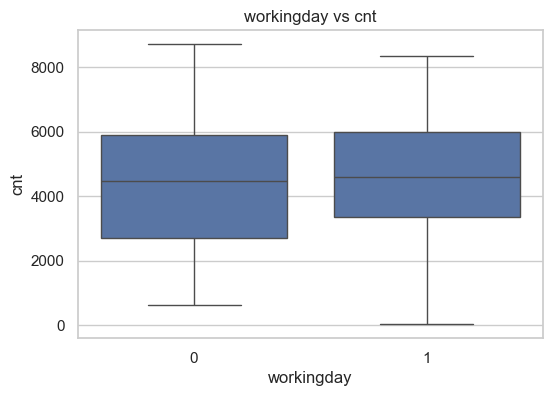

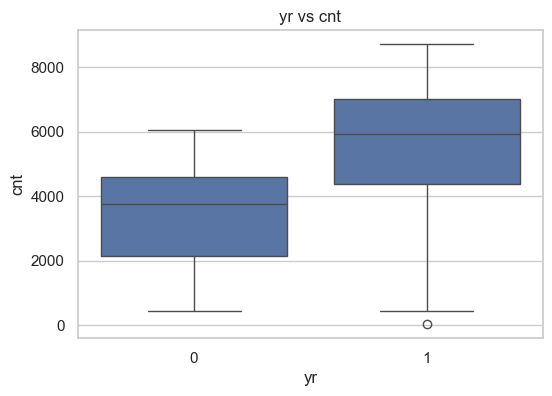

In [19]:

# Histograms
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
plt.figure(figsize=(12, 8))
for i, col in enumerate(num_cols):
    plt.subplot((len(num_cols)//3)+1, 3, i+1)
    sns.histplot(df[col], kde=True)
    plt.title(col)
plt.tight_layout()
plt.show()

# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# Boxplots: categorical vs target
categorical = ['season','mnth','weekday','weathersit','holiday','workingday','yr']
for col in categorical:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=col, y='cnt', data=df)
    plt.title(f"{col} vs cnt")
    plt.show()


## 6. Data Preprocessing
Steps:
1. Convert categorical columns to `category` type.
2. Apply **one-hot encoding** with `drop_first=True` to avoid dummy variable trap.
3. Convert dummy variables to integers (0/1).


In [20]:

# Convert to categorical
for c in categorical:
    df[c] = df[c].astype('category')

# One-hot encode
X = pd.get_dummies(df.drop(columns=['cnt','casual','registered']), drop_first=True).astype(int)
y = df['cnt']

print("Feature matrix shape:", X.shape)
X.head()


Feature matrix shape: (730, 31)


,temp,atemp,hum,windspeed,day,is_weekend,season_2,season_3,season_4,yr_1,...,holiday_1,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6,workingday_1,weathersit_2,weathersit_3
0,14,18,80,10,1,1,0,0,0,0,...,0,0,0,0,0,0,1,0,1,0
1,14,17,69,16,2,1,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
2,8,9,43,16,3,0,0,0,0,0,...,0,1,0,0,0,0,0,1,0,0
3,8,10,59,10,4,0,0,0,0,0,...,0,0,1,0,0,0,0,1,0,0
4,9,11,43,12,5,0,0,0,0,0,...,0,0,0,1,0,0,0,1,0,0


## 7. Train-Test Split
- **Training set:** 70% of data
- **Testing set:** 30% of data
We split before scaling to avoid data leakage.


In [21]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


## 8. Multicollinearity Check (VIF)
- Calculate VIF for each feature.
- Drop `temp` because it is highly correlated with `atemp` (VIF > 100).
Reducing multicollinearity makes coefficients more stable and interpretable.


In [22]:

# Calculate VIF
X_vif = sm.add_constant(X_train)
vif_data = pd.DataFrame()
vif_data['feature'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

print(vif_data.sort_values(by='VIF', ascending=False))

# Drop one of highly collinear features (temp vs atemp)
if 'temp' in X_train.columns:
    X_train.drop(columns=['temp'], inplace=True)
    X_test.drop(columns=['temp'], inplace=True)


         feature         VIF
6     is_weekend         inf
24     weekday_2         inf
26     weekday_4         inf
27     weekday_5         inf
29  workingday_1         inf
25     weekday_3         inf
23     weekday_1         inf
22     holiday_1         inf
1           temp  137.668513
2          atemp  125.597656
8       season_3   11.864309
16        mnth_7   10.262858
7       season_2    9.427087
9       season_4    8.377820
17        mnth_8    8.116255
15        mnth_6    8.043351
14        mnth_5    7.793169
18        mnth_9    7.398800
13        mnth_4    6.440578
19       mnth_10    6.128262
20       mnth_11    5.615303
21       mnth_12    2.873077
12        mnth_3    2.339470
3            hum    2.064805
11        mnth_2    1.784296
28     weekday_6    1.727037
30  weathersit_2    1.638881
31  weathersit_3    1.342128
4      windspeed    1.332495
10          yr_1    1.059274
5            day    1.034265
0          const    0.000000


## 9. Feature Scaling
We scale **only numeric columns** (excluding dummy variables) using `StandardScaler` for numerical stability in regression.


In [23]:

num_features = X_train.select_dtypes(include=['float64', 'int64']).columns
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_features] = scaler.fit_transform(X_train[num_features])
X_test_scaled[num_features] = scaler.transform(X_test[num_features])


## 10. OLS Model (Statsmodels)
Fit an Ordinary Least Squares (OLS) model on the training set.
Benefits:
- Detailed statistical output (p-values, confidence intervals)
- R² and Adjusted R² for model fit


In [24]:

X_train_sm = sm.add_constant(X_train)
ols_model = sm.OLS(y_train, X_train_sm).fit()
print(ols_model.summary())


                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.848
Model:                            OLS   Adj. R-squared:                  0.839
Method:                 Least Squares   F-statistic:                     95.70
Date:                Wed, 13 Aug 2025   Prob (F-statistic):          3.50e-177
Time:                        15:02:13   Log-Likelihood:                -4112.1
No. Observations:                 511   AIC:                             8282.
Df Residuals:                     482   BIC:                             8405.
Df Model:                          28                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const          930.4940    206.288      4.511   

## 11. Linear Regression Model (scikit-learn)
Fit a `LinearRegression` model on scaled data.
This is used for prediction and performance evaluation.


In [25]:

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

print("Intercept:", lr.intercept_)
coeff_df = pd.DataFrame({'feature': X_train_scaled.columns, 'coefficient': lr.coef_})
coeff_df.sort_values(by='coefficient', key=lambda s: s.abs(), ascending=False).head(20)


Intercept: 4552.951076320939


,feature,coefficient
8,yr_1,979.488535
7,season_4,808.304589
0,atemp,798.976292
5,season_2,567.133820
6,season_3,539.392500
29,weathersit_3,-319.484180
28,weathersit_2,-234.980080
16,mnth_9,192.796299
1,hum,-189.480673
2,windspeed,-160.853549


## 12. Model Evaluation & Diagnostics
Metrics:
- **RMSE**: Average prediction error
- **R²**: Proportion of variance explained

Diagnostics:
- Histogram of residuals (should be symmetric around zero)
- Residuals vs Predicted values (check for patterns)
- Q-Q plot (check residual normality)


RMSE: 779.03
R^2: 0.8364


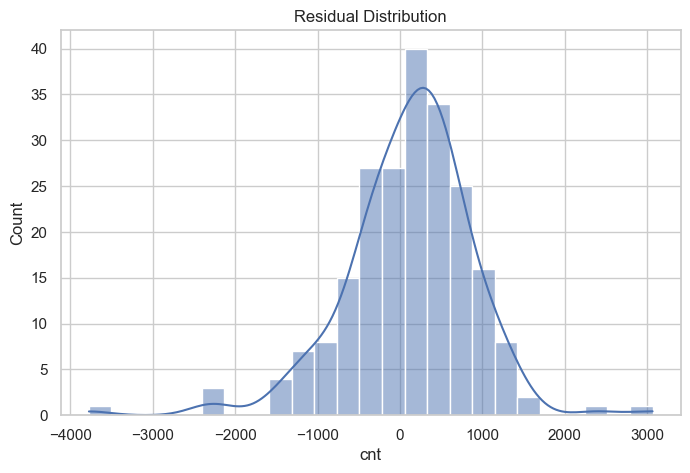

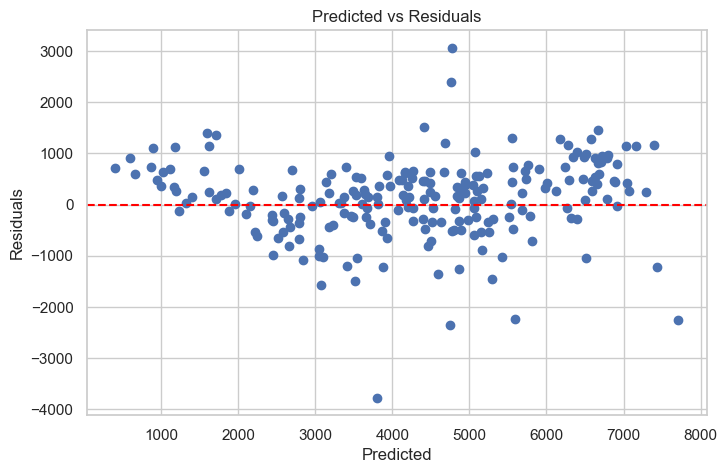

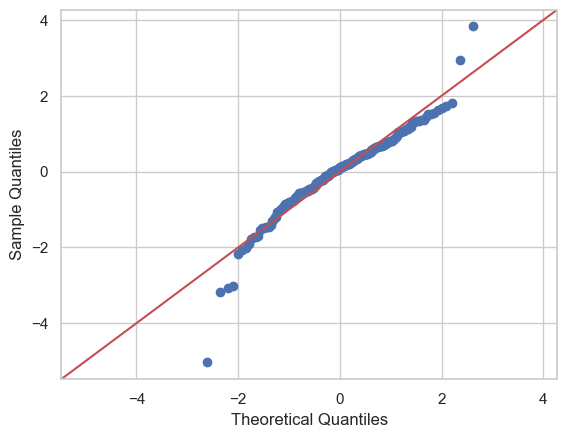

In [26]:

y_pred = lr.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.2f}")
print(f"R^2: {r2:.4f}")

# Residual diagnostics
residuals = y_test - y_pred

plt.figure(figsize=(8,5))
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

plt.figure(figsize=(8,5))
plt.scatter(y_pred, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Predicted vs Residuals")
plt.show()

sm.qqplot(residuals, line='45', fit=True)
plt.show()


## 13. Final Regression Equation
We display the final regression equation in LaTeX format for professional presentation.


In [27]:

from IPython.display import display, Math

eq_parts = [f"{lr.intercept_:.2f}"]
for coef, feat in zip(lr.coef_, X_train_scaled.columns):
    sign = "+" if coef >= 0 else "-"
    eq_parts.append(f"{sign} {abs(coef):.2f} \\cdot {feat}")

latex_eq = "\\hat{cnt} = " + " ".join(eq_parts)
display(Math(latex_eq))


<IPython.core.display.Math object>